In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [56]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [57]:
print(df.shape)

df.info()

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [58]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

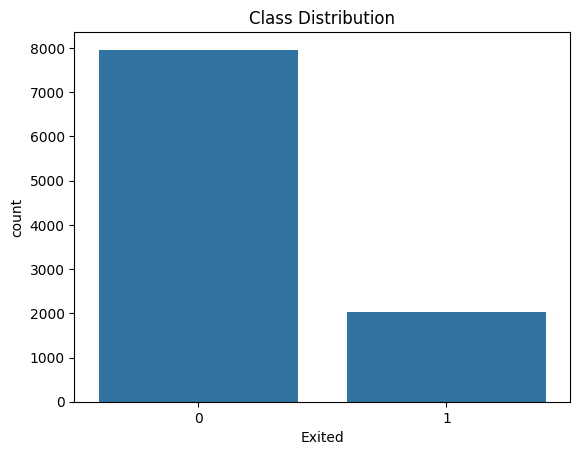

In [59]:
sns.countplot(x='Exited', data=df)
plt.title("Class Distribution")
plt.show()

In [60]:
df.drop(
    columns=['RowNumber','CustomerId','Surname'],
    inplace=True
)

In [61]:
X = df.drop('Exited', axis=1)

y = df['Exited']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
categorical_features = [
    'Geography',
    'Gender'
]

numerical_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(drop='first'),
            categorical_features
        ),
        (
            'num',
            StandardScaler(),
            numerical_features
        )
    ]
)

In [65]:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [66]:
print("Logistic Regression")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("ROC AUC:",
      roc_auc_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Logistic Regression
Accuracy: 0.72
ROC AUC: 0.7117317625792201
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



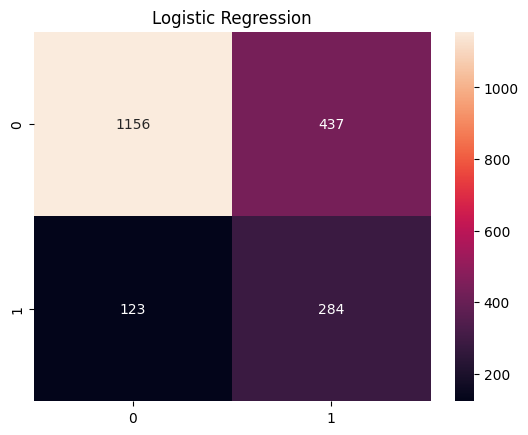

In [67]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Logistic Regression")
plt.show()

In [68]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [69]:
print("Random Forest")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("ROC AUC:",
      roc_auc_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest
Accuracy: 0.8495
ROC AUC: 0.7482081465132312
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1593
           1       0.65      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.84      0.85      0.85      2000



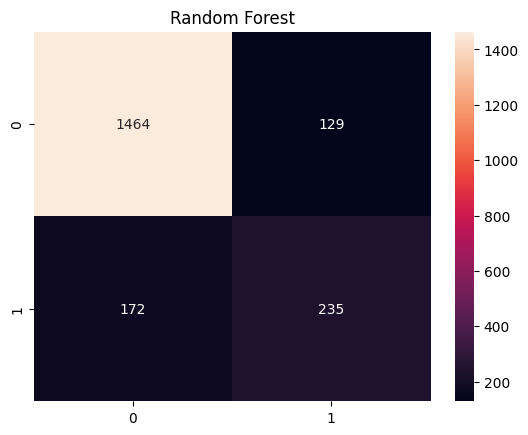

In [70]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Random Forest")
plt.show()

In [71]:
gb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)

In [72]:
print("Gradient Boosting")

print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("ROC AUC:",
      roc_auc_score(y_test, y_pred_gb))

print(classification_report(
    y_test,
    y_pred_gb
))

Gradient Boosting
Accuracy: 0.843
ROC AUC: 0.7715666359734156
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.61      0.65      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.85      2000



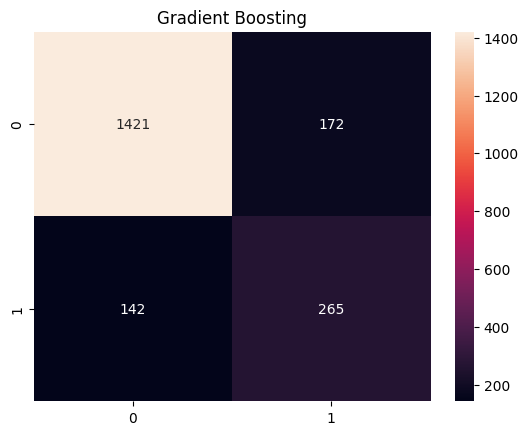

In [73]:
cm = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Gradient Boosting")
plt.show()

In [74]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_gb)
    ],
    'ROC_AUC':[
        roc_auc_score(y_test,y_pred_lr),
        roc_auc_score(y_test,y_pred_rf),
        roc_auc_score(y_test,y_pred_gb)
    ]
})

results.sort_values(
    by='ROC_AUC',
    ascending=False
)

,Model,Accuracy,ROC_AUC
2,Gradient Boosting,0.8430,0.771567
1,Random Forest,0.8495,0.748208
0,Logistic Regression,0.7200,0.711732


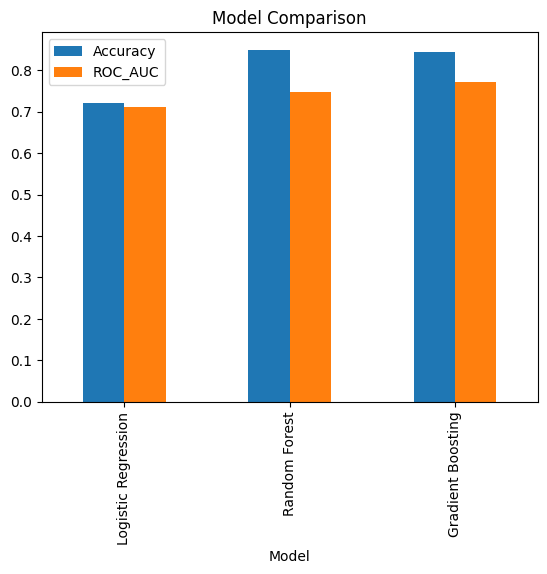

In [75]:
results.plot(
    x='Model',
    y=['Accuracy','ROC_AUC'],
    kind='bar'
)

plt.title("Model Comparison")
plt.show()

In [76]:
new_customer = pd.DataFrame({
    'CreditScore':[700],
    'Geography':['Germany'],
    'Gender':['Male'],
    'Age':[45],
    'Tenure':[4],
    'Balance':[120000],
    'NumOfProducts':[1],
    'HasCrCard':[1],
    'IsActiveMember':[0],
    'EstimatedSalary':[50000]
})

prediction = rf_pipeline.predict(new_customer)

if prediction[0] == 1:
    print("Customer likely to churn")
else:
    print("Customer likely to stay")

Customer likely to churn
